In [1]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns
import random


from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [11, 12, 65],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }



all_specs_label = []
all_specs = np.empty((0, 60))
# all_specs = np.empty((0, 31293))
file_list = []
pathname = '/scratch/dazhang/MATLAB/'
for patient, channal_list in pt_ch_mapping.items():
    print(patient, channal_list)
    path = pathname + patient+'/'
    ls_specs = np.empty((0, 60))
    # ls_specs = np.empty((0, 31293))

    for cur_channel in channal_list:
        cur_channel = str(cur_channel) 
        cur_channel_list = []   
        for filename in glob.glob(os.path.join(path, '*.mat')):
            
                # each_file = 'ls_ripple_'+str(patient)+'_Channel_' + str(cur_channel) + '_binsize_10_Block_'+str(blk)+'.mat'
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(os.path.join(os.getcwd(), filename), 'r') as f: 
                if "Channel_"+str(cur_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)

    all_specs_label = np.concatenate([all_specs_label, [patient]*len(ls_specs)])
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

print(all_specs.shape, all_specs_label.shape)

# exit(0)
test_shape2 = []
all_spikes_label = np.empty((0, 1))
manual_label_spikes = list()
for each_file in file_list:
    patient_name = each_file.split("/")[-2]
    actural_file = each_file.split("/")[-1]
    actural_file_list = actural_file.split("_")
    spike_file_name = pathname + patient_name+"/"+actural_file_list[0]+"_spikes_"+"_".join(actural_file_list[2:6])+"_1_"+"_".join(actural_file_list[7:])

    with open(spike_file_name, 'r') as f: 
        spikes = loadmat(spike_file_name)['ls_spikes']


    all_spikes_label = np.concatenate([all_spikes_label, spikes])

all_ripples = all_specs
print(all_ripples.shape)
all_vectors = np.asarray(all_ripples)

EC130_200 [1, 13]
EC133_200 [282, 291, 292, 293]
EC135_200 [303]
EC137_200 [257, 258, 259, 269]
EC143_200 [339]
EC157_200 [321, 332, 333, 334]
EC162_200 [85, 86]
EC175_200 [301, 302]
EC183_200 [290]
EC186_200 [299, 300, 301]
EC187_200 [309, 310]
EC191_200 [2, 3, 4]
EC196_200 [300, 301, 303]
EC219_200 [399, 400, 402, 403]
EC220_200 [53, 54, 76, 77]
EC221_200 [376, 377]
EC222_200 [267, 268, 269, 270]
(31847, 60) (31847,)
(31847, 60)


Running UMAP: n_neighbors=5, min_dist=0.0


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Running UMAP: n_neighbors=5, min_dist=0.1


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP: n_neighbors=5, min_dist=0.2


...

Running UMAP: n_neighbors=200, min_dist=0.3


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Running UMAP: n_neighbors=200, min_dist=0.5


/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Global x range: -7.0058966 12.707718
Global y range: -2.7677362 16.169764


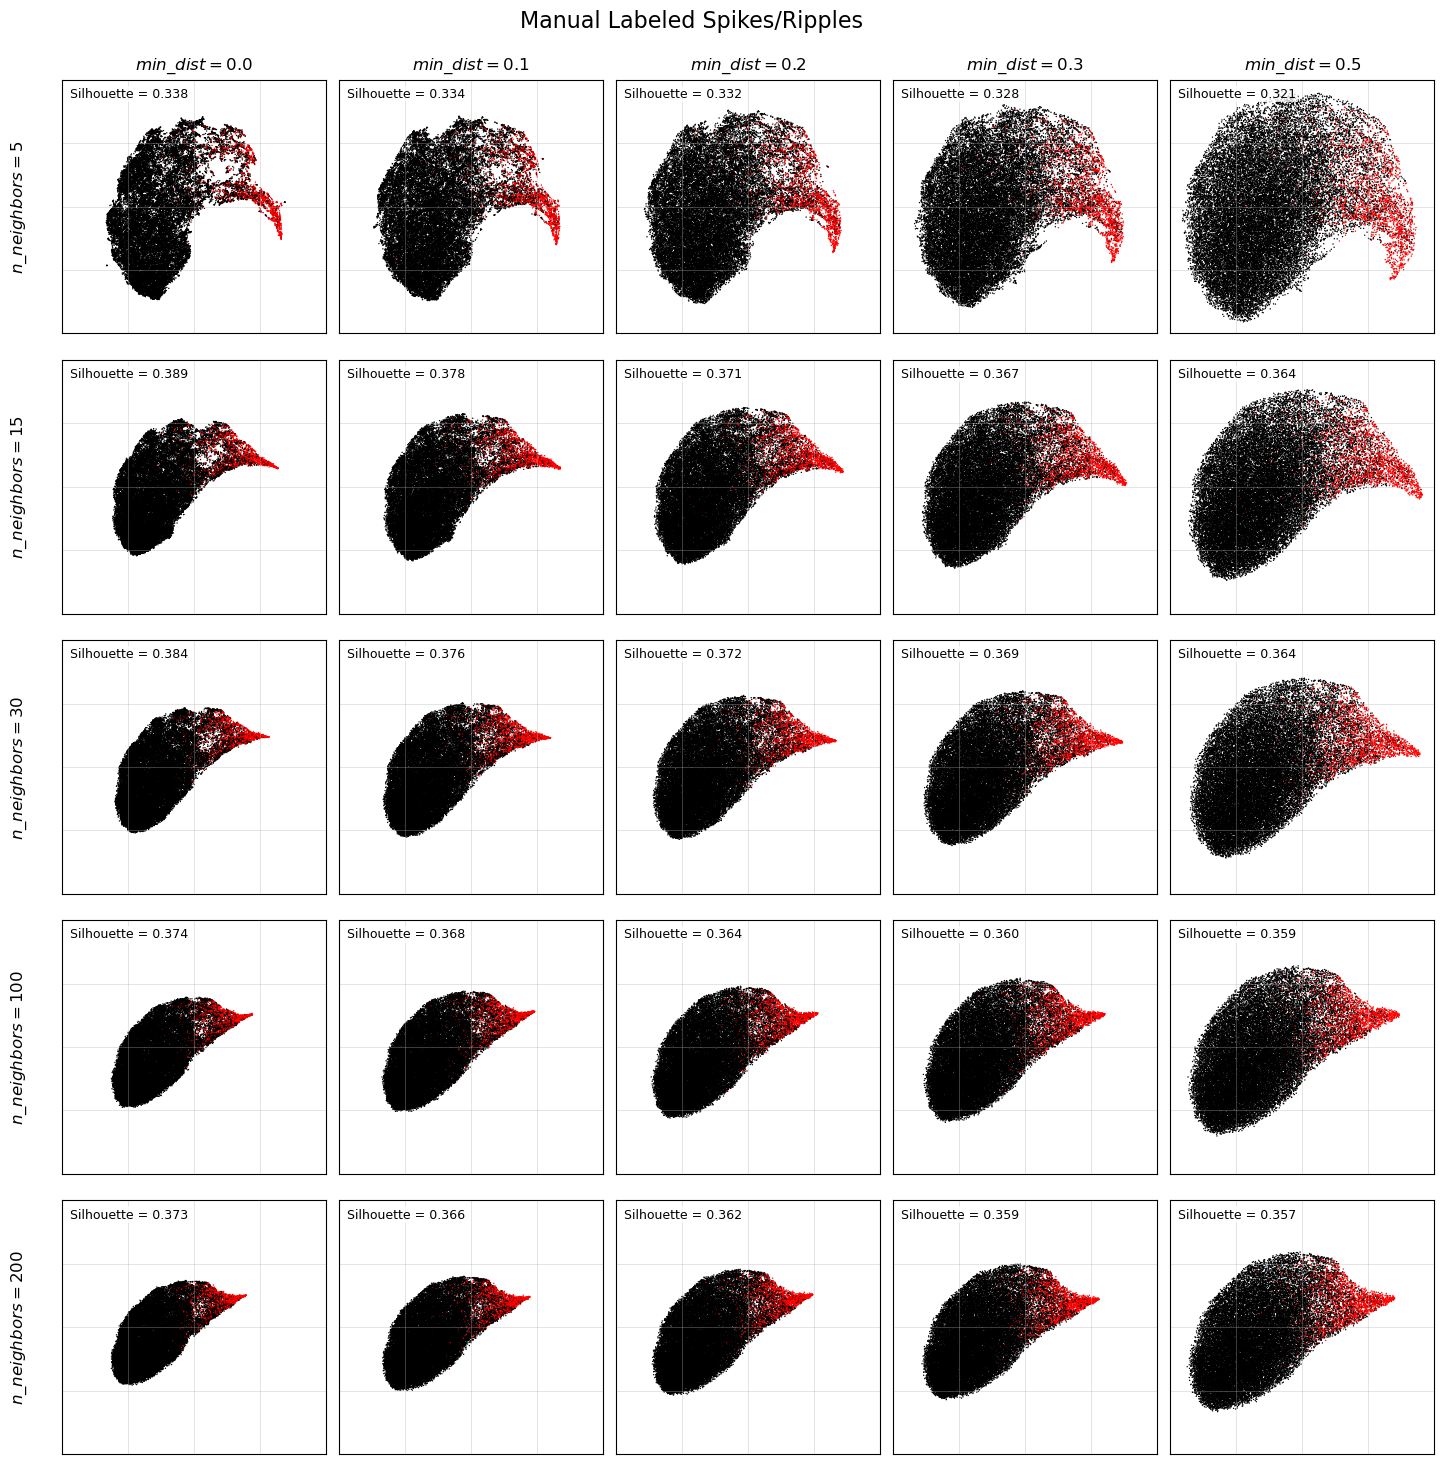

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import umap

from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D

n_neighbors_list = [5, 15, 30, 100, 200]
min_dist_list = [0.0, 0.1, 0.2, 0.3, 0.5]

all_spikes_label = np.ravel(all_spikes_label)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12
})

# ============================================================
# Colors
# 0 = ripple -> black
# 1 = spike  -> red
# ============================================================
c_list = []
for spike in all_spikes_label:
    if spike == 0:
        c_list.append([0, 0, 0])
    else:
        c_list.append([1, 0, 0])

# ============================================================
# First pass: compute all embeddings and scores
# ============================================================
results = {}

global_x_min = np.inf
global_x_max = -np.inf
global_y_min = np.inf
global_y_max = -np.inf

for i, n_nei in enumerate(n_neighbors_list):
    for j, min_d in enumerate(min_dist_list):

        print(f"Running UMAP: n_neighbors={n_nei}, min_dist={min_d}")

        embedding = umap.UMAP(
            n_components=2,
            min_dist=min_d,
            metric="euclidean",
            n_neighbors=n_nei,
            random_state=42,
            n_epochs=100,
            verbose=False
        ).fit_transform(all_vectors)

        actual_score = silhouette_score(embedding, all_spikes_label)

        results[(i, j)] = {
            "embedding": embedding,
            "score": actual_score,
            "n_neighbors": n_nei,
            "min_dist": min_d
        }

        global_x_min = min(global_x_min, np.min(embedding[:, 0]))
        global_x_max = max(global_x_max, np.max(embedding[:, 0]))
        global_y_min = min(global_y_min, np.min(embedding[:, 1]))
        global_y_max = max(global_y_max, np.max(embedding[:, 1]))

# add padding so points do not touch panel borders
x_pad = 0.05 * (global_x_max - global_x_min)
y_pad = 0.05 * (global_y_max - global_y_min)

x_min_plot = global_x_min - x_pad
x_max_plot = global_x_max + x_pad
y_min_plot = global_y_min - y_pad
y_max_plot = global_y_max + y_pad

print("Global x range:", x_min_plot, x_max_plot)
print("Global y range:", y_min_plot, y_max_plot)

# ============================================================
# Rows    = n_neighbors
# Columns = min_dist
# ============================================================
fig, axes = plt.subplots(
    nrows=len(n_neighbors_list),
    ncols=len(min_dist_list),
    figsize=(15, 15)
)

for i, n_nei in enumerate(n_neighbors_list):
    for j, min_d in enumerate(min_dist_list):

        ax = axes[i, j]
        embedding = results[(i, j)]["embedding"]
        actual_score = results[(i, j)]["score"]

        ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=c_list,
            s=1,
            linewidths=0,
            rasterized=True
        )

        # unified limits across all subplots
        ax.set_xlim(x_min_plot, x_max_plot)
        ax.set_ylim(y_min_plot, y_max_plot)
        ax.set_aspect("equal", adjustable="box")


        ax.set_xticks(np.linspace(x_min_plot, x_max_plot, 5))
        ax.set_yticks(np.linspace(y_min_plot, y_max_plot, 5))

        # Hide tick labels and tick marks
        ax.tick_params(
            axis="both",
            which="both",
            length=0,
            labelbottom=False,
            labelleft=False
        )

        # Show grid
        ax.grid(
            True,
            linestyle="-",
            linewidth=0.6,
            alpha=0.4
        )

        # light border
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

        # column titles
        if i == 0:
            ax.set_title(
                rf"$min\_dist = {min_d}$",
                fontsize=12,
                pad=8
            )

        # row labels on the left
        if j == 0:
            ax.text(
                -0.16,
                0.5,
                rf"$n\_neighbors = {n_nei}$",
                transform=ax.transAxes,
                rotation=90,
                ha="center",
                va="center",
                fontsize=12
            )

        # compact silhouette text inside each subplot
        ax.text(
            0.03,
            0.97,
            f"Silhouette = {actual_score:.3f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
                pad=1.2
            )
        )

fig.suptitle("Manual Labeled Spikes/Ripples", fontsize=16,  y=0.985)


# tighter spacing
plt.subplots_adjust(
    left=0.08,
    right=0.995,
    bottom=0.02,
    top=0.94,
    wspace=0.05,
    hspace=0.08
)

fig.savefig(
    "UMAP_parameter_sensitivity_5x5_grid.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

fig.savefig(
    "UMAP_parameter_sensitivity_5x5_grid.pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.show()
plt.close(fig)